# Module 6 — Meal Planner
We generate a meal plan for 7/30/90 days.
Meals are not repeated more than once every 5 days.
Each meal shows a main course and two alternatives.

## 1.Importing libraries

In [36]:
import pandas as pd
import numpy as np
import pickle
import warnings
import subprocess
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

subprocess.run(['pip', 'install', 'deep-translator', '-q'])
from deep_translator import GoogleTranslator

with open('../models/kbzhu_model.pkl', 'rb') as f:
    kbzhu_data = pickle.load(f)
kbzhu_model    = kbzhu_data['model']
activity_order = kbzhu_data['activity_order']

with open('../models/recommender_vectors.pkl', 'rb') as f:
    rec_data = pickle.load(f)
kazakh_recipes  = rec_data['kazakh_recipes']
foodcom_recipes = rec_data['foodcom_recipes']

all_recipes = kazakh_recipes.copy()

print('Модель КБЖУ загружена')
print('Казахских блюд:', len(kazakh_recipes))
print('Food.com блюд:', len(foodcom_recipes))
print('Всего рецептов:', len(all_recipes))

Модель КБЖУ загружена
Казахских блюд: 142
Food.com блюд: 217511
Всего рецептов: 142


## 2.Translation function

In [37]:
def translate_to_russian(text):
    """Переводим текст на русский. Если уже русский — возвращаем как есть."""
    try:
        if any('а' <= c <= 'я' or 'А' <= c <= 'Я' for c in str(text)):
            return text
        translator = GoogleTranslator(source='en', target='ru')
        return translator.translate(str(text))
    except:
        return text


print('Переводчик готов')
print('Тест:', translate_to_russian('chicken breast with rice'))

Переводчик готов
Тест: куриная грудка с рисом


## 3.Function of prediction KBZHU

In [38]:
def suggest_goal_days(current_weight, target_weight):
    diff = abs(target_weight - current_weight)
    if diff == 0:
        return 90
    elif target_weight > current_weight:
        weeks = diff / 0.4
    else:
        weeks = diff / 0.7
    return max(int(weeks * 7), 30)


def predict_kbzhu(gender, age, height, weight, target_weight,
                  activity='moderate', goal_days=None):
    suggested = False
    if goal_days is None:
        goal_days = suggest_goal_days(weight, target_weight)
        suggested = True

    gender_enc   = 0 if gender == 'female' else 1
    activity_enc = activity_order[activity]
    weight_diff  = target_weight - weight

    X_input = pd.DataFrame([{
        'gender_encoded':   gender_enc,
        'age':              age,
        'height':           height,
        'weight':           weight,
        'weight_diff':      weight_diff,
        'activity_encoded': activity_enc,
        'goal_days':        goal_days
    }])

    pred = kbzhu_model.predict(X_input)[0]
    return {
        'calories':       round(pred[0]),
        'protein':        round(pred[1]),
        'fat':            round(pred[2]),
        'carbs':          round(pred[3]),
        'goal_days':      goal_days,
        'suggested_days': suggested
    }


print('Функция КБЖУ создана')

Функция КБЖУ создана


## 4.Function of recommendation dishes

In [39]:
MEAL_CATEGORY = {
    'Завтрак':         'breakfast',
    'Перекус':         'snack',
    'Обед':            'main',
    'Ужин':            'main',
    'Поздний перекус': 'snack'
}


def recommend_dish(target_cal, target_prot, target_fat, target_carbs,
                   max_minutes, recipes_df, meal_type=None,
                   exclude_names=None, top_n=3):
    """
    exclude_names — список ОРИГИНАЛЬНЫХ (английских) имён блюд.
    Так исключение работает правильно даже после перевода.
    """
    df = recipes_df.copy()
    df = df[df['minutes'] <= max_minutes * 3]
    df = df.dropna(subset=['calories', 'protein', 'fat', 'carbs'])

    # Убираем мусорные рецепты — напитки, маринады, соусы
    df = df[df['calories'] >= 80]
    df = df[~((df['protein'] == 0) & (df['fat'] == 0))]
    df = df[~((df['protein'] <= 1) & (df['fat'] <= 1) & (df['carbs'] <= 5))]

    # Фильтруем по категории приёма пищи
    if meal_type and 'category' in df.columns:
        cat = MEAL_CATEGORY.get(meal_type)
        if cat:
            cat_df = df[df['category'] == cat]
            if len(cat_df) >= 5:
                df = cat_df

    if exclude_names:
        df = df[~df['name'].isin(exclude_names)]

    if len(df) == 0:
        return None

    features = ['calories', 'protein', 'fat', 'carbs', 'minutes']
    sc = MinMaxScaler()
    vecs = sc.fit_transform(df[features])

    target = np.array([[target_cal, target_prot, target_fat,
                        target_carbs, max_minutes]])
    target_vec = sc.transform(target)

    sims = cosine_similarity(target_vec, vecs)[0]
    top_idx = sims.argsort()[-top_n:][::-1]

    results = []
    for idx in top_idx:
        row = df.iloc[idx]
        rec_cal       = round(row['calories'])
        original_name = row['name']          # оригинальное имя для истории
        name_ru       = translate_to_russian(original_name)  # переведённое для показа

        if rec_cal > 0 and rec_cal < target_cal * 0.7:
            portions = round(target_cal / rec_cal, 1)
            portion_note = f'рекомендуем {portions} порции = {round(rec_cal * portions)} ккал'
        else:
            portions = 1
            portion_note = ''

        results.append({
            'name':          name_ru,       # показываем пользователю
            'original_name': original_name, # используем для исключения
            'calories':      rec_cal,
            'protein':       round(row['protein']),
            'fat':           round(row['fat']),
            'carbs':         round(row['carbs']),
            'minutes':       int(row['minutes']),
            'portions':      portions,
            'portion_note':  portion_note
        })
    return results

print('Функция recommend_dish создана')

Функция recommend_dish создана


## 5.Function of schedule by time

In [41]:
def build_schedule(wake_time, sleep_time, kbzhu):
    wake_h  = int(wake_time.split(':')[0])
    sleep_h = int(sleep_time.split(':')[0])

    # Правильный расчёт сна — переход через полночь
    if sleep_h < wake_h:
        sleep_h_adjusted = sleep_h + 24
    else:
        sleep_h_adjusted = sleep_h

    cal  = kbzhu['calories']
    prot = kbzhu['protein']
    fat  = kbzhu['fat']
    carb = kbzhu['carbs']

    dinner_h     = min(sleep_h_adjusted - 5, 18) % 24
    late_snack_h = min(sleep_h_adjusted - 3, 20) % 24

    return [
        {
            'приём':       'Подъём',
            'время':       f'{wake_h:02d}:00',
            'is_meal':     False,
            'действие':    'Выпить стакан воды'
        },
        {
            'приём':       'Завтрак',
            'время':       f'{wake_h+1:02d}:00',
            'is_meal':     True,
            'calories':    round(cal  * 0.25),
            'protein':     round(prot * 0.25),
            'fat':         round(fat  * 0.25),
            'carbs':       round(carb * 0.25),
            'max_minutes': 20
        },
        {
            'приём':       'Перекус',
            'время':       f'{wake_h+3:02d}:30',
            'is_meal':     True,
            'calories':    round(cal  * 0.10),
            'protein':     round(prot * 0.10),
            'fat':         round(fat  * 0.10),
            'carbs':       round(carb * 0.10),
            'max_minutes': 10
        },
        {
            'приём':       'Обед',
            'время':       f'{wake_h+5:02d}:00',
            'is_meal':     True,
            'calories':    round(cal  * 0.35),
            'protein':     round(prot * 0.35),
            'fat':         round(fat  * 0.35),
            'carbs':       round(carb * 0.35),
            'max_minutes': 60
        },
        {
            'приём':       'Ужин',
            'время':       f'{dinner_h:02d}:00',
            'is_meal':     True,
            'calories':    round(cal  * 0.25),
            'protein':     round(prot * 0.25),
            'fat':         round(fat  * 0.25),
            'carbs':       round(carb * 0.25),
            'max_minutes': 45
        },
        {
            'приём':       'Поздний перекус',
            'время':       f'{late_snack_h:02d}:00',
            'is_meal':     True,
            'calories':    round(cal  * 0.05),
            'protein':     round(prot * 0.05),
            'fat':         round(fat  * 0.05),
            'carbs':       round(carb * 0.05),
            'max_minutes': 5
        },
        {
            'приём':       'Сон',
            'время':       f'{sleep_h:02d}:00',
            'is_meal':     False,
            'действие':    f'Сон ({sleep_h} часов)'
        }
    ]


print('Функция расписания создана')
test = build_schedule('08:00', '23:00',
                      {'calories':2200,'protein':110,'fat':70,'carbs':270})
print('Сон:', test[-1]['действие'])

Функция расписания создана
Сон: Сон (23 часов)


## 6.Main function of generation plan

In [42]:
def generate_meal_plan(gender, age, height, weight, target_weight,
                       activity='moderate', goal_days=None,
                       wake_time='08:00', sleep_time='23:00',
                       plan_days=7):

    kbzhu    = predict_kbzhu(gender, age, height, weight,
                             target_weight, activity, goal_days)
    schedule = build_schedule(wake_time, sleep_time, kbzhu)

    # Храним ОРИГИНАЛЬНЫЕ имена для правильного исключения
    recent_meals = []
    WINDOW = 5 * 5
    plan   = []

    for day in range(1, plan_days + 1):
        day_plan = {'день': day, 'расписание': []}

        for slot in schedule:
            if not slot['is_meal']:
                day_plan['расписание'].append({
                    'приём':    slot['приём'],
                    'время':    slot['время'],
                    'is_meal':  False,
                    'действие': slot['действие']
                })
                continue

            dishes = recommend_dish(
                target_cal    = slot['calories'],
                target_prot   = slot['protein'],
                target_fat    = slot['fat'],
                target_carbs  = slot['carbs'],
                max_minutes   = slot['max_minutes'],
                recipes_df    = all_recipes,
                meal_type     = slot['приём'],
                exclude_names = recent_meals,
                top_n         = 3
            )

            if dishes is None or len(dishes) == 0:
                recent_meals = []
                dishes = recommend_dish(
                    slot['calories'], slot['protein'],
                    slot['fat'], slot['carbs'],
                    slot['max_minutes'], all_recipes,
                    meal_type=slot['приём'], top_n=3
                )

            if dishes:
                main_dish    = dishes[0]
                alternatives = dishes[1:]

                # Сохраняем ОРИГИНАЛЬНОЕ имя в историю
                recent_meals.append(main_dish['original_name'])
                if len(recent_meals) > WINDOW:
                    recent_meals = recent_meals[-WINDOW:]

                day_plan['расписание'].append({
                    'приём':        slot['приём'],
                    'время':        slot['время'],
                    'is_meal':      True,
                    'блюдо':        main_dish['name'],  # русское имя
                    'калории':      main_dish['calories'],
                    'белки':        main_dish['protein'],
                    'жиры':         main_dish['fat'],
                    'углеводы':     main_dish['carbs'],
                    'минуты':       main_dish['minutes'],
                    'порции':       main_dish['portions'],
                    'заметка':      main_dish['portion_note'],
                    'альтернативы': [d['name'] for d in alternatives]
                })

        plan.append(day_plan)

    return plan, kbzhu


print('Планировщик готов')

Планировщик готов


## 7.Plan for 7 days

In [43]:
plan, kbzhu = generate_meal_plan(
    gender        = 'female',
    age           = 20,
    height        = 157,
    weight        = 47,
    target_weight = 50,
    activity      = 'moderate',
    wake_time     = '08:00',
    sleep_time    = '23:00',
    plan_days     = 7
)

print('ПЛАН ПИТАНИЯ НА 7 ДНЕЙ')
print(f"Суточная норма: {kbzhu['calories']} ккал | "
      f"Б:{kbzhu['protein']}г | Ж:{kbzhu['fat']}г | У:{kbzhu['carbs']}г")
if kbzhu['suggested_days']:
    print(f"Срок достижения цели: {kbzhu['goal_days']} дней "
          f"(план обновляется каждые 7 дней)")

for day_plan in plan:
    print(f"ДЕНЬ {day_plan['день']}")


    for slot in day_plan['расписание']:
        if not slot['is_meal']:
            print(f"  {slot['время']}  {slot['приём']} — {slot['действие']}")
        else:
            print(f"  {slot['время']}  {slot['приём']}: {slot['блюдо']}")
            print(f"           {slot['калории']} ккал | "
                  f"Б:{slot['белки']}г | Ж:{slot['жиры']}г | "
                  f"У:{slot['углеводы']}г | {slot['минуты']} мин")
            if slot['заметка']:
                print(f"{slot['заметка']}")
            if slot['альтернативы']:
                print(f"Альтернативы: {' / '.join(slot['альтернативы'])}")

ПЛАН ПИТАНИЯ НА 7 ДНЕЙ
Суточная норма: 2242 ккал | Б:99г | Ж:62г | У:321г
Срок достижения цели: 52 дней (план обновляется каждые 7 дней)
ДЕНЬ 1
  08:00  Подъём — Выпить стакан воды
  09:00  Завтрак: Бутерброд с яйцом
           260 ккал | Б:12г | Ж:12г | У:26г | 8 мин
рекомендуем 2.2 порции = 572 ккал
Альтернативы: Сырники со сметаной / Каша гречневая с молоком
  11:30  Перекус: Лаваш с сыром
           300 ккал | Б:14г | Ж:12г | У:34г | 5 мин
Альтернативы: Хлебцы с творогом / Мюсли с молоком
  13:00  Обед: Спагетти болоньезе
           480 ккал | Б:24г | Ж:16г | У:58г | 35 мин
рекомендуем 1.6 порции = 768 ккал
Альтернативы: Макароны по-флотски / Макароны с сыром
  18:00  Ужин: Макароны по-флотски
           480 ккал | Б:24г | Ж:18г | У:54г | 30 мин
Альтернативы: Макароны с сыром / Рис с курицей
  20:00  Поздний перекус: Яйцо варёное
           120 ккал | Б:10г | Ж:8г | У:1г | 10 мин
Альтернативы: Хлебцы с творогом / Тост с джемом
  23:00  Сон — Сон (23 часов)
ДЕНЬ 2
  08:00  Подъём — 

## 8.Calories for everyday

Всего приёмов пищи за 7 дней: 35
Уникальных блюд: 29
Повторений: 6


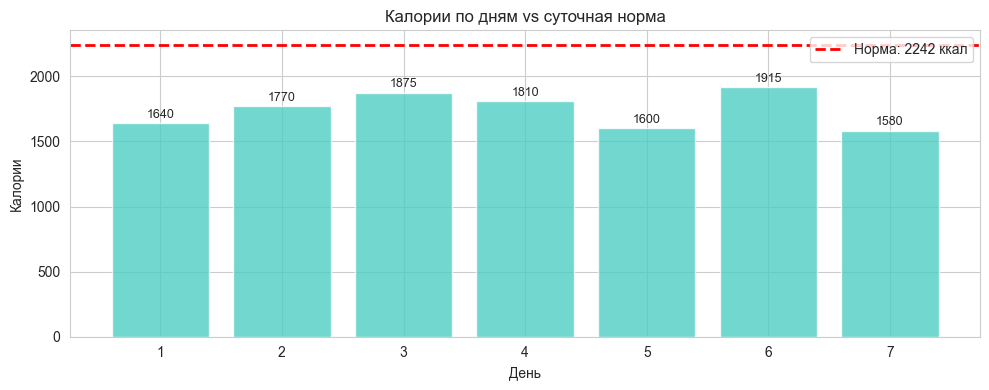

График сохранён


In [44]:
all_dishes     = []
daily_calories = []

for day_plan in plan:
    day_cal = 0
    for slot in day_plan['расписание']:
        if slot['is_meal']:
            all_dishes.append(slot['блюдо'])
            day_cal += slot['калории']
    daily_calories.append(day_cal)

print(f'Всего приёмов пищи за 7 дней: {len(all_dishes)}')
print(f'Уникальных блюд: {len(set(all_dishes))}')
print(f'Повторений: {len(all_dishes) - len(set(all_dishes))}')

plt.figure(figsize=(10, 4))
bars = plt.bar(range(1, 8), daily_calories, color='#4ECDC4', alpha=0.8)
plt.axhline(y=kbzhu['calories'], color='red', linestyle='--',
            linewidth=2, label=f"Норма: {kbzhu['calories']} ккал")
plt.title('Калории по дням vs суточная норма')
plt.xlabel('День')
plt.ylabel('Калории')
plt.legend()
plt.xticks(range(1, 8))
for bar, cal in zip(bars, daily_calories):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(cal), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/clean/meal_plan_calories.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён')

## 9.Saving plan to csv

In [45]:
rows = []
for day_plan in plan:
    for slot in day_plan['расписание']:
        if slot['is_meal']:
            rows.append({
                'день':          day_plan['день'],
                'приём_пищи':    slot['приём'],
                'время':         slot['время'],
                'блюдо':         slot['блюдо'],
                'калории':       slot['калории'],
                'белки':         slot['белки'],
                'жиры':          slot['жиры'],
                'углеводы':      slot['углеводы'],
                'время_готовки': slot['минуты'],
                'порции':        slot['порции'],
                'заметка':       slot['заметка'],
                'альтернативы':  ' / '.join(slot['альтернативы'])
            })

plan_df = pd.DataFrame(rows)
plan_df.to_csv('../data/clean/meal_plan_7days.csv',
               index=False, encoding='utf-8-sig')

print('План сохранён: data/clean/meal_plan_7days.csv')
print()
print(plan_df.to_string())

План сохранён: data/clean/meal_plan_7days.csv

    день       приём_пищи  время                       блюдо  калории  белки  жиры  углеводы  время_готовки  порции                            заметка                                        альтернативы
0      1          Завтрак  09:00           Бутерброд с яйцом      260     12    12        26              8     2.2  рекомендуем 2.2 порции = 572 ккал      Сырники со сметаной / Каша гречневая с молоком
1      1          Перекус  11:30               Лаваш с сыром      300     14    12        34              5     1.0                                                    Хлебцы с творогом / Мюсли с молоком
2      1             Обед  13:00          Спагетти болоньезе      480     24    16        58             35     1.6  рекомендуем 1.6 порции = 768 ккал              Макароны по-флотски / Макароны с сыром
3      1             Ужин  18:00         Макароны по-флотски      480     24    18        54             30     1.0                          